In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/Users/anamikasaroha/Energy7_Week1/week_9/WCR_latest_TWS_cleaned_V2.csv')
df.head()

,Time,Site Name,Point Machine Name,Direction,A Current,A Voltage,B Current,B Voltage,Type of A,Type of B,Polling of A,Polling of B
0,2024-12-15 10:20:59,ARNETHA,101/102,Reverse,"[0.0, 1.7, 4.9, 4.1, 3.3, 2.7, 2.3, 2.1, 1.9, ...","[0.0, 52.5, 79.5, 94.5, 100.5, 105.0, 106.5, 1...","[0.0, 3.9, 5.2, 4.1, 3.2, 2.6, 2.3, 2.1, 2.0, ...","[0.0, 103.5, 103.5, 103.5, 100.5, 97.5, 94.5, ...",TWS,TWS,20,20
1,2024-12-15 10:21:08,ARNETHA,101/102,Normal,"[0.0, 5.2, 4.6, 3.7, 3.0, 2.6, 2.2, 2.1, 2.0, ...","[0.0, 85.5, 90.0, 97.5, 103.5, 106.5, 109.5, 1...","[0.0, 1.5, 4.7, 3.9, 3.2, 2.7, 2.4, 2.1, 2.0, ...","[0.0, 12.0, 45.0, 73.5, 90.0, 99.0, 105.0, 108...",TWS,TWS,20,20
2,2024-12-16 07:28:55,ARNETHA,101/102,Normal,"[0.0, 5.2, 4.5, 3.6, 3.0, 2.6, 2.2, 2.1, 2.0, ...","[0.0, 91.5, 97.5, 102.0, 106.5, 108.0, 109.5, ...","[0.5, 4.6, 4.0, 3.3, 2.8, 2.4, 2.1, 2.0, 2.0, ...","[0.0, 40.5, 70.5, 88.5, 99.0, 103.5, 106.5, 10...",TWS,TWS,20,20
3,2024-12-16 07:28:46,ARNETHA,101/102,Reverse,"[0.0, 4.7, 4.3, 3.4, 2.8, 2.4, 2.1, 2.0, 2.0, ...","[0.0, 46.5, 76.5, 91.5, 100.5, 103.5, 105.0, 1...","[0.0, 3.6, 5.2, 4.1, 3.2, 2.7, 2.3, 2.1, 2.1, ...","[0.0, 103.5, 105.0, 103.5, 103.5, 103.5, 100.5...",TWS,TWS,20,20
4,2024-12-17 11:16:32,ARNETHA,101/102,Reverse,"[0.0, 3.2, 4.7, 3.8, 3.0, 2.6, 2.2, 2.0, 1.9, ...","[0.0, 22.5, 54.0, 79.5, 94.5, 102.0, 106.5, 10...","[0.0, 3.9, 5.0, 3.9, 3.1, 2.6, 2.2, 2.0, 2.0, ...","[0.0, 97.5, 88.5, 97.5, 103.5, 106.5, 109.5, 1...",TWS,TWS,20,20


In [3]:
df.shape

(11397, 12)

In [4]:
# Count the number of unique sites in the DataFrame 'df'
num_sites = df['Site Name'].nunique()
print(f"Number of unique sites: {num_sites}")

# Optionally, display the list of unique site names
unique_sites = df['Site Name'].unique()
print("Site Names:", unique_sites)

Number of unique sites: 2
Site Names: ['ARNETHA' 'Dadhdevi']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Deep Learning and ML libraries 

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, RepeatVector, TimeDistributed, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Time series analysis 

In [7]:
from statsmodels.tsa.seasonal import STL
from scipy import signal
from scipy.stats import zscore
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

In [8]:
# Report generation
from reportlab.lib.pagesizes import letter, A4
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, PageBreak
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors

import ast
import json
from typing import Dict, List, Tuple, Optional
import logging

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


In [9]:
class RailwayPredictiveMaintenance:
    """
    Comprehensive predictive maintenance system for railway point machines
    """
    
    def __init__(self):
        self.data = None
        self.processed_data = None
        self.models = {}
        self.scalers = {}
        self.anomaly_threshold = 0.95
        self.alert_log = []
        
    def load_and_parse_data(self, file_path: str) -> pd.DataFrame:
        """
        Load and parse CSV data with proper handling of array columns
        """
        try:
            # Read the CSV file
            df = pd.read_csv(file_path)
            
            # Parse timestamp
            df['Time'] = pd.to_datetime(df['Time'])
            
            # Parse array columns (Current A, Current B, Voltage A, Voltage B)
            array_columns = ['A Current', 'A Voltage', 'B Current', 'B Voltage']
            
            for col in array_columns:
                if col in df.columns:
                    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
            
            # Create machine ID from site and point machine name
            df['Machine_ID'] = df['Site Name'] + '_' + df['Point Machine Name']
            
            self.data = df
            logger.info(f"Successfully loaded {len(df)} records from {df['Machine_ID'].nunique()} machines")
            return df
            
        except Exception as e:
            logger.error(f"Error loading data: {str(e)}")
            raise
    
    def extract_temporal_features(self, current_array: List[float]) -> Dict:
        """
        Extract comprehensive temporal features from current signal arrays
        """
        if not current_array or len(current_array) == 0:
            return self._get_default_features()
        
        try:
            current_array = np.array([x for x in current_array if x is not None and not np.isnan(x)])
            
            if len(current_array) == 0:
                return self._get_default_features()
            
            # Peak detection
            peaks, _ = signal.find_peaks(current_array, height=np.mean(current_array))
            peak_values = current_array[peaks] if len(peaks) > 0 else [0]
            
            # Sort peaks by magnitude
            peak_values_sorted = sorted(peak_values, reverse=True)
            
            # Calculate peak ratio (second peak > first peak condition)
            first_peak = peak_values_sorted[0] if len(peak_values_sorted) > 0 else 0
            second_peak = peak_values_sorted[1] if len(peak_values_sorted) > 1 else 0
            peak_ratio = second_peak / first_peak if first_peak > 0 else 0
            
            # Signal energy and statistical features
            signal_energy = np.sum(current_array ** 2)
            signal_power = signal_energy / len(current_array)
            
            features = {
                'peak_count': len(peaks),
                'first_peak': first_peak,
                'second_peak': second_peak,
                'peak_ratio': peak_ratio,
                'signal_energy': signal_energy,
                'signal_power': signal_power,
                'mean_current': np.mean(current_array),
                'std_current': np.std(current_array),
                'max_current': np.max(current_array),
                'min_current': np.min(current_array),
                'rms_current': np.sqrt(np.mean(current_array ** 2)),
                'signal_duration': len(current_array),
                'rise_time': self._calculate_rise_time(current_array),
                'settling_time': self._calculate_settling_time(current_array),
                'overshoot': self._calculate_overshoot(current_array),
                'anomaly_flag_peaks': 1 if peak_ratio > 1.0 else 0  # Second peak > first peak
            }
            
            return features
            
        except Exception as e:
            logger.warning(f"Error extracting features: {str(e)}")
            return self._get_default_features()
    
    def _get_default_features(self) -> Dict:
        """Return default feature values for error cases"""
        return {
            'peak_count': 0, 'first_peak': 0, 'second_peak': 0, 'peak_ratio': 0,
            'signal_energy': 0, 'signal_power': 0, 'mean_current': 0, 'std_current': 0,
            'max_current': 0, 'min_current': 0, 'rms_current': 0, 'signal_duration': 0,
            'rise_time': 0, 'settling_time': 0, 'overshoot': 0, 'anomaly_flag_peaks': 0
        }
    
    def _calculate_rise_time(self, signal_array: np.ndarray) -> float:
        """Calculate 10% to 90% rise time"""
        try:
            max_val = np.max(signal_array)
            min_val = np.min(signal_array)
            
            ten_percent = min_val + 0.1 * (max_val - min_val)
            ninety_percent = min_val + 0.9 * (max_val - min_val)
            
            ten_idx = np.where(signal_array >= ten_percent)[0]
            ninety_idx = np.where(signal_array >= ninety_percent)[0]
            
            if len(ten_idx) > 0 and len(ninety_idx) > 0:
                return ninety_idx[0] - ten_idx[0]
            return 0
        except:
            return 0
    
    def _calculate_settling_time(self, signal_array: np.ndarray) -> float:
        """Calculate settling time (time to reach steady state)"""
        try:
            if len(signal_array) < 10:
                return len(signal_array)
            
            # Consider last 20% as steady state
            steady_state_start = int(0.8 * len(signal_array))
            steady_state_mean = np.mean(signal_array[steady_state_start:])
            threshold = 0.05 * steady_state_mean  # 5% tolerance
            
            for i in range(len(signal_array) - 1, -1, -1):
                if abs(signal_array[i] - steady_state_mean) > threshold:
                    return len(signal_array) - i
            return 0
        except:
            return 0
    
    def _calculate_overshoot(self, signal_array: np.ndarray) -> float:
        """Calculate percentage overshoot"""
        try:
            max_val = np.max(signal_array)
            final_val = signal_array[-1] if len(signal_array) > 0 else 0
            
            if final_val > 0:
                return ((max_val - final_val) / final_val) * 100
            return 0
        except:
            return 0
    
    def process_data_pipeline(self) -> pd.DataFrame:
        """
        Comprehensive data processing pipeline with multi-scale decomposition
        """
        if self.data is None:
            raise ValueError("No data loaded. Please load data first.")
        
        processed_records = []
        
        for idx, row in self.data.iterrows():
            try:
                # Extract features for Current A and B
                features_a = self.extract_temporal_features(row['A Current'])
                features_b = self.extract_temporal_features(row['B Current'])
                
                # Create processed record
                record = {
                    'timestamp': row['Time'],
                    'machine_id': row['Machine_ID'],
                    'site_name': row['Site Name'],
                    'point_machine_name': row['Point Machine Name'],
                    'direction': row['Direction'],
                    'hour': row['Time'].hour,
                    'day_of_week': row['Time'].dayofweek,
                    'month': row['Time'].month,
                }
                
                # Add Current A features with prefix
                for key, value in features_a.items():
                    record[f'current_a_{key}'] = value
                
                # Add Current B features with prefix
                for key, value in features_b.items():
                    record[f'current_b_{key}'] = value
                
                # Combined features
                record['combined_peak_ratio'] = (features_a['peak_ratio'] + features_b['peak_ratio']) / 2
                record['combined_signal_energy'] = features_a['signal_energy'] + features_b['signal_energy']
                record['energy_balance'] = abs(features_a['signal_energy'] - features_b['signal_energy'])
                
                # Rule-based anomaly detection
                record['anomaly_flag'] = max(features_a['anomaly_flag_peaks'], features_b['anomaly_flag_peaks'])
                
                processed_records.append(record)
                
            except Exception as e:
                logger.warning(f"Error processing row {idx}: {str(e)}")
                continue
        
        # Create DataFrame
        self.processed_data = pd.DataFrame(processed_records)
        
        # Multi-scale time decomposition
        self._apply_stl_decomposition()
        
        # Calculate risk scores
        self._calculate_risk_scores()
        
        logger.info(f"Processed {len(self.processed_data)} records successfully")
        return self.processed_data
    
    def _apply_stl_decomposition(self):
        """
        Apply STL decomposition for trend analysis at different time scales
        """
        try:
            for machine_id in self.processed_data['machine_id'].unique():
                machine_data = self.processed_data[self.processed_data['machine_id'] == machine_id].copy()
                machine_data = machine_data.sort_values('timestamp').reset_index(drop=True)
                
                if len(machine_data) < 10:  # Need minimum data points
                    continue
                
                # Hourly aggregation for trend analysis
                machine_data['hour_group'] = machine_data['timestamp'].dt.floor('H')
                hourly_data = machine_data.groupby('hour_group').agg({
                    'combined_peak_ratio': 'mean',
                    'combined_signal_energy': 'mean'
                }).reset_index()
                
                if len(hourly_data) >= 24:  # Need at least 24 hours for daily seasonality
                    try:
                        # STL decomposition for peak ratio
                        stl_peak = STL(hourly_data['combined_peak_ratio'], seasonal=13)
                        decomposition_peak = stl_peak.fit()
                        
                        # Store decomposition results
                        for i, timestamp in enumerate(hourly_data['hour_group']):
                            mask = (self.processed_data['machine_id'] == machine_id) & \
                                  (self.processed_data['timestamp'].dt.floor('H') == timestamp)
                            
                            if i < len(decomposition_peak.trend):
                                self.processed_data.loc[mask, 'trend_peak_ratio'] = decomposition_peak.trend.iloc[i]
                                self.processed_data.loc[mask, 'seasonal_peak_ratio'] = decomposition_peak.seasonal.iloc[i]
                                self.processed_data.loc[mask, 'residual_peak_ratio'] = decomposition_peak.resid.iloc[i]
                            
                    except Exception as e:
                        logger.warning(f"STL decomposition failed for machine {machine_id}: {str(e)}")
                        
        except Exception as e:
            logger.error(f"Error in STL decomposition: {str(e)}")
    
    def _calculate_risk_scores(self):
        """
        Calculate comprehensive risk scores for maintenance prioritization
        """
        # Normalize features for risk calculation
        scaler = MinMaxScaler()
        
        risk_features = ['combined_peak_ratio', 'combined_signal_energy', 'energy_balance']
        
        # Handle missing values
        for feature in risk_features:
            if feature not in self.processed_data.columns:
                self.processed_data[feature] = 0
        
        # Fill any remaining NaN values
        self.processed_data[risk_features] = self.processed_data[risk_features].fillna(0)
        
        # Scale features
        scaled_features = scaler.fit_transform(self.processed_data[risk_features])
        
        # Calculate risk score: 0.7*(peak_ratio) + 0.3*(signal_energy)
        self.processed_data['risk_score'] = (
            0.7 * scaled_features[:, 0] +  # peak_ratio
            0.3 * scaled_features[:, 1]    # signal_energy
        )
        
        # Add energy balance factor
        self.processed_data['risk_score'] *= (1 + 0.1 * scaled_features[:, 2])  # energy_balance
        
        # Clip to [0, 1] range
        self.processed_data['risk_score'] = np.clip(self.processed_data['risk_score'], 0, 1)
    
    def build_lstm_autoencoder(self, input_shape: Tuple[int, int]) -> Model:
        """
        Build LSTM Autoencoder for unsupervised anomaly detection
        """
        # Encoder
        input_layer = Input(shape=input_shape)
        encoder = LSTM(64, activation='relu', return_sequences=True)(input_layer)
        encoder = Dropout(0.2)(encoder)
        encoder = LSTM(32, activation='relu', return_sequences=False)(encoder)
        encoder = Dropout(0.2)(encoder)
        
        # Decoder
        decoder = RepeatVector(input_shape[0])(encoder)
        decoder = LSTM(32, activation='relu', return_sequences=True)(decoder)
        decoder = Dropout(0.2)(decoder)
        decoder = LSTM(64, activation='relu', return_sequences=True)(decoder)
        decoder = TimeDistributed(Dense(input_shape[1]))(decoder)
        
        # Model
        autoencoder = Model(input_layer, decoder)
        autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        
        return autoencoder
    
    def train_anomaly_detection_models(self):
        """
        Train multiple anomaly detection models
        """
        if self.processed_data is None:
            raise ValueError("No processed data available. Please process data first.")
        
        # Prepare features for ML models
        feature_columns = [
            'combined_peak_ratio', 'combined_signal_energy', 'energy_balance',
            'current_a_mean_current', 'current_b_mean_current',
            'current_a_std_current', 'current_b_std_current',
            'current_a_max_current', 'current_b_max_current',
            'current_a_rms_current', 'current_b_rms_current'
        ]
        
        # Filter available columns
        available_features = [col for col in feature_columns if col in self.processed_data.columns]
        
        if not available_features:
            logger.warning("No suitable features found for model training")
            return
        
        # Prepare data
        X = self.processed_data[available_features].fillna(0)
        
        # 1. Isolation Forest for anomaly detection
        iso_forest = IsolationForest(contamination=0.1, random_state=42)
        iso_predictions = iso_forest.fit_predict(X)
        self.processed_data['anomaly_isolation_forest'] = (iso_predictions == -1).astype(int)
        self.models['isolation_forest'] = iso_forest
        
        # 2. Statistical anomaly detection (Z-score based)
        z_scores = np.abs(zscore(X, axis=0, nan_policy='omit'))
        z_score_anomalies = (z_scores > 3).any(axis=1)
        self.processed_data['anomaly_zscore'] = z_score_anomalies.astype(int)
        
        # 3. LSTM Autoencoder (if enough data)
        try:
            if len(X) >= 100:  # Minimum data requirement
                # Prepare sequence data for LSTM
                scaler = StandardScaler()
                X_scaled = scaler.fit_transform(X)
                self.scalers['lstm_scaler'] = scaler
                
                # Create sequences
                sequence_length = min(10, len(X) // 10)
                X_sequences = self._create_sequences(X_scaled, sequence_length)
                
                if len(X_sequences) > 50:  # Minimum sequences for training
                    # Build and train LSTM autoencoder
                    lstm_model = self.build_lstm_autoencoder((sequence_length, X_scaled.shape[1]))
                    
                    # Train model
                    early_stopping = EarlyStopping(patience=10, restore_best_weights=True)
                    lstm_model.fit(
                        X_sequences, X_sequences,
                        epochs=50, batch_size=32,
                        validation_split=0.2,
                        callbacks=[early_stopping],
                        verbose=0
                    )
                    
                    # Calculate reconstruction error
                    X_pred = lstm_model.predict(X_sequences, verbose=0)
                    reconstruction_error = np.mean(np.square(X_sequences - X_pred), axis=(1, 2))
                    
                    # Set threshold for anomalies
                    threshold = np.percentile(reconstruction_error, 95)
                    lstm_anomalies = reconstruction_error > threshold
                    
                    # Map back to original data
                    lstm_anomaly_flags = np.zeros(len(self.processed_data))
                    lstm_anomaly_flags[:len(lstm_anomalies)] = lstm_anomalies
                    self.processed_data['anomaly_lstm'] = lstm_anomaly_flags
                    
                    self.models['lstm_autoencoder'] = lstm_model
                    
        except Exception as e:
            logger.warning(f"LSTM model training failed: {str(e)}")
        
        # Combine anomaly flags
        anomaly_columns = [col for col in self.processed_data.columns if col.startswith('anomaly_')]
        if anomaly_columns:
            self.processed_data['combined_anomaly_flag'] = (
                self.processed_data[anomaly_columns].sum(axis=1) >= 2
            ).astype(int)
        
        logger.info("Anomaly detection models trained successfully")
    
    def _create_sequences(self, data: np.ndarray, sequence_length: int) -> np.ndarray:
        """Create sequences for LSTM training"""
        sequences = []
        for i in range(len(data) - sequence_length + 1):
            sequences.append(data[i:(i + sequence_length)])
        return np.array(sequences)
    
    def generate_alerts(self) -> List[Dict]:
        """
        Generate real-time alerts based on anomaly detection and risk scores
        """
        if self.processed_data is None:
            raise ValueError("No processed data available")
        
        alerts = []
        current_time = datetime.now()
        
        # High-risk machines
        high_risk_machines = self.processed_data[self.processed_data['risk_score'] > 0.8]
        
        for _, row in high_risk_machines.iterrows():
            alert = {
                'timestamp': current_time,
                'machine_id': row['machine_id'],
                'alert_level': 'HIGH',
                'risk_score': row['risk_score'],
                'suggested_action': 'Immediate inspection required - High risk score detected',
                'details': f"Peak ratio: {row.get('combined_peak_ratio', 0):.3f}, Energy: {row.get('combined_signal_energy', 0):.2f}"
            }
            alerts.append(alert)
        
        # Anomaly-based alerts
        if 'combined_anomaly_flag' in self.processed_data.columns:
            anomaly_machines = self.processed_data[self.processed_data['combined_anomaly_flag'] == 1]
            
            for _, row in anomaly_machines.iterrows():
                if row['risk_score'] <= 0.8:  # Don't duplicate high-risk alerts
                    alert = {
                        'timestamp': current_time,
                        'machine_id': row['machine_id'],
                        'alert_level': 'MEDIUM',
                        'risk_score': row['risk_score'],
                        'suggested_action': 'Schedule preventive maintenance - Anomaly detected',
                        'details': f"Multiple anomaly indicators triggered"
                    }
                    alerts.append(alert)
        
        # Peak ratio alerts (second peak > first peak)
        peak_anomalies = self.processed_data[self.processed_data['anomaly_flag'] == 1]
        
        for _, row in peak_anomalies.iterrows():
            if row['risk_score'] <= 0.6:  # Don't duplicate higher priority alerts
                alert = {
                    'timestamp': current_time,
                    'machine_id': row['machine_id'],
                    'alert_level': 'LOW',
                    'risk_score': row['risk_score'],
                    'suggested_action': 'Monitor closely - Peak pattern anomaly detected',
                    'details': f"Second peak exceeds first peak"
                }
                alerts.append(alert)
        
        self.alert_log.extend(alerts)
        logger.info(f"Generated {len(alerts)} alerts")
        
        return alerts
    
    def create_operational_dashboard_data(self) -> Dict:
        """
        Prepare data for operational dashboard visualization
        """
        if self.processed_data is None:
            raise ValueError("No processed data available")
        
        dashboard_data = {
            'time_series': self.processed_data.copy(),
            'anomaly_summary': self._get_anomaly_summary(),
            'machine_health': self._get_machine_health_summary(),
            'alert_distribution': self._get_alert_distribution()
        }
        
        return dashboard_data
    
    def _get_anomaly_summary(self) -> Dict:
        """Get anomaly detection summary statistics"""
        anomaly_cols = [col for col in self.processed_data.columns if col.startswith('anomaly_')]
        
        summary = {
            'total_records': len(self.processed_data),
            'total_anomalies': 0,
            'anomaly_rate': 0,
            'by_type': {}
        }
        
        if anomaly_cols:
            for col in anomaly_cols:
                anomaly_count = self.processed_data[col].sum()
                summary['by_type'][col] = {
                    'count': int(anomaly_count),
                    'rate': float(anomaly_count / len(self.processed_data))
                }
            
            if 'combined_anomaly_flag' in self.processed_data.columns:
                summary['total_anomalies'] = int(self.processed_data['combined_anomaly_flag'].sum())
                summary['anomaly_rate'] = float(summary['total_anomalies'] / len(self.processed_data))
        
        return summary
    
    def _get_machine_health_summary(self) -> Dict:
        """Get machine health summary by machine ID"""
        health_summary = self.processed_data.groupby('machine_id').agg({
            'risk_score': ['mean', 'max', 'std'],
            'combined_peak_ratio': 'mean',
            'combined_signal_energy': 'mean',
            'anomaly_flag': 'sum'
        }).round(3)
        
        # Flatten column names
        health_summary.columns = ['_'.join(col).strip() for col in health_summary.columns]
        
        return health_summary.to_dict('index')
    
    def _get_alert_distribution(self) -> Dict:
        """Get alert level distribution"""
        if not self.alert_log:
            return {'HIGH': 0, 'MEDIUM': 0, 'LOW': 0}
        
        alert_df = pd.DataFrame(self.alert_log)
        distribution = alert_df['alert_level'].value_counts().to_dict()
        
        # Ensure all levels are represented
        for level in ['HIGH', 'MEDIUM', 'LOW']:
            if level not in distribution:
                distribution[level] = 0
        
        return distribution
    
    def save_alert_log(self, filename: str = 'alert_log.csv'):
        """
        Save alert log to CSV file
        """
        if not self.alert_log:
            logger.warning("No alerts to save")
            return
        
        alert_df = pd.DataFrame(self.alert_log)
        alert_df.to_csv(filename, index=False)
        logger.info(f"Alert log saved to {filename}")
    
    def save_processed_data(self, filename: str = 'processed_railway_data.csv'):
        """
        Save processed data to CSV file
        """
        if self.processed_data is None:
            logger.warning("No processed data to save")
            return
        
        self.processed_data.to_csv(filename, index=False)
        logger.info(f"Processed data saved to {filename}")


In [11]:
def main(csv_file_path):
    
    # Initialize the system
    pm_system = RailwayPredictiveMaintenance()

    try:
        # Load and process data from the provided CSV file path
        print("Loading data...")
        pm_system.load_and_parse_data(csv_file_path)
        
        print("Processing data pipeline...")
        processed_data = pm_system.process_data_pipeline()
        
        print("Training anomaly detection models...")
        pm_system.train_anomaly_detection_models()
        
        print("Generating alerts...")
        alerts = pm_system.generate_alerts()
        
        print("Creating dashboard data...")
        dashboard_data = pm_system.create_operational_dashboard_data()
        
        # Display results
        print(f"\n=== PROCESSING SUMMARY ===")
        print(f"Total records processed: {len(processed_data)}")
        print(f"Machines monitored: {processed_data['machine_id'].nunique()}")
        print(f"Alerts generated: {len(alerts)}")
        print(f"Average risk score: {processed_data['risk_score'].mean():.3f}")
        
        if alerts:
            print(f"\n=== RECENT ALERTS ===")
            for alert in alerts[:5]:  # Show first 5 alerts
                print(f"Machine: {alert['machine_id']} | Level: {alert['alert_level']} | "
                      f"Risk: {alert['risk_score']:.3f} | Action: {alert['suggested_action']}")
        
        # Save outputs
        print(f"\nSaving results...")
        pm_system.save_processed_data('processed_railway_data.csv')
        pm_system.save_alert_log('alert_log.csv')
        
        print("Process completed successfully!")
        
    except Exception as e:
        print(f"Error: {e}")

In [12]:
main('/Users/anamikasaroha/Energy7_Week1/week_9/WCR_latest_TWS_cleaned_V2.csv')

Loading data...


2025-06-22 09:59:46,761 - INFO - Successfully loaded 11397 records from 8 machines


Processing data pipeline...


2025-06-22 09:59:49,251 - WARNING - STL decomposition failed for machine ARNETHA_101/102: Unable to determine period from endog
2025-06-22 09:59:49,254 - WARNING - STL decomposition failed for machine ARNETHA_119/120: Unable to determine period from endog
2025-06-22 09:59:49,257 - WARNING - STL decomposition failed for machine ARNETHA_117/118: Unable to determine period from endog
2025-06-22 09:59:49,260 - WARNING - STL decomposition failed for machine Dadhdevi_PT 101/102: Unable to determine period from endog
2025-06-22 09:59:49,262 - WARNING - STL decomposition failed for machine Dadhdevi_PT 105/106: Unable to determine period from endog
2025-06-22 09:59:49,264 - WARNING - STL decomposition failed for machine Dadhdevi_PT 113/114: Unable to determine period from endog
2025-06-22 09:59:49,268 - WARNING - STL decomposition failed for machine Dadhdevi_PT 121/122: Unable to determine period from endog
2025-06-22 09:59:49,271 - WARNING - STL decomposition failed for machine Dadhdevi_PT 119

Training anomaly detection models...


2025-06-22 10:01:48,982 - INFO - Anomaly detection models trained successfully
2025-06-22 10:01:48,997 - INFO - Generated 516 alerts


Generating alerts...
Creating dashboard data...

=== PROCESSING SUMMARY ===
Total records processed: 11397
Machines monitored: 8
Alerts generated: 516
Average risk score: 0.495

=== RECENT ALERTS ===
Machine: ARNETHA_117/118 | Level: HIGH | Risk: 1.000 | Action: Immediate inspection required - High risk score detected
Machine: ARNETHA_101/102 | Level: MEDIUM | Risk: 0.000 | Action: Schedule preventive maintenance - Anomaly detected
Machine: ARNETHA_101/102 | Level: MEDIUM | Risk: 0.000 | Action: Schedule preventive maintenance - Anomaly detected
Machine: ARNETHA_101/102 | Level: MEDIUM | Risk: 0.633 | Action: Schedule preventive maintenance - Anomaly detected
Machine: ARNETHA_101/102 | Level: MEDIUM | Risk: 0.000 | Action: Schedule preventive maintenance - Anomaly detected

Saving results...


2025-06-22 10:01:49,201 - INFO - Processed data saved to processed_railway_data.csv
2025-06-22 10:01:49,205 - INFO - Alert log saved to alert_log.csv


Process completed successfully!


In [13]:
def generate_machine_health_report(pm_system, output_file='machine_health_report.pdf'):
    """
    Generate comprehensive PDF health report
    """
    if pm_system.processed_data is None:
        print("No processed data available for report generation")
        return
    
    try:
        # Create PDF document
        doc = SimpleDocTemplate(output_file, pagesize=A4)
        styles = getSampleStyleSheet()
        story = []
        
        # Title
        title_style = ParagraphStyle(
            'CustomTitle',
            parent=styles['Heading1'],
            fontSize=24,
            spaceAfter=30,
            alignment=1  # Center alignment
        )
        story.append(Paragraph("Railway Point Machine Health Report", title_style))
        story.append(Spacer(1, 20))
        
        # Executive Summary
        story.append(Paragraph("Executive Summary", styles['Heading2']))
        
        # Calculate summary statistics
        total_machines = pm_system.processed_data['machine_id'].nunique()
        avg_risk = pm_system.processed_data['risk_score'].mean()
        high_risk_count = len(pm_system.processed_data[pm_system.processed_data['risk_score'] > 0.8])
        total_anomalies = pm_system.processed_data.get('combined_anomaly_flag', pd.Series([0])).sum()
        
        summary_text = f"""
        • Total Machines Monitored: {total_machines}
        • Average Risk Score: {avg_risk:.3f}
        • High-Risk Machines: {high_risk_count}
        • Total Anomalies Detected: {total_anomalies}
        • Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
        """
        
        story.append(Paragraph(summary_text, styles['Normal']))
        story.append(Spacer(1, 20))
        
        # Risk Score Analysis
        story.append(Paragraph("Risk Score Analysis", styles['Heading2']))
        
        # Machine ranking by risk score
        machine_risk = pm_system.processed_data.groupby('machine_id')['risk_score'].agg(['mean', 'max', 'std']).reset_index()
        machine_risk = machine_risk.sort_values('mean', ascending=False)
        
        # Create table data
        table_data = [['Machine ID', 'Avg Risk', 'Max Risk', 'Risk Std Dev', 'Priority']]
        
        for idx, row in machine_risk.head(10).iterrows():
            priority = 'HIGH' if row['mean'] > 0.7 else 'MEDIUM' if row['mean'] > 0.4 else 'LOW'
            table_data.append([
                row['machine_id'],
                f"{row['mean']:.3f}",
                f"{row['max']:.3f}",
                f"{row['std']:.3f}",
                priority
            ])
        
        # Create table
        table = Table(table_data)
        table.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
            ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
            ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
            ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
            ('FONTSIZE', (0, 0), (-1, 0), 12),
            ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
            ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
            ('GRID', (0, 0), (-1, -1), 1, colors.black)
        ]))
        
        story.append(table)
        story.append(PageBreak())
        
        # Maintenance Recommendations
        story.append(Paragraph("Maintenance Recommendations", styles['Heading2']))
        
        recommendations = []
        
        # High-risk machines
        high_risk_machines = machine_risk[machine_risk['mean'] > 0.7]['machine_id'].tolist()
        if high_risk_machines:
            recommendations.append(f"IMMEDIATE ACTION REQUIRED: {len(high_risk_machines)} machines with high risk scores need immediate inspection: {', '.join(high_risk_machines[:3])}{'...' if len(high_risk_machines) > 3 else ''}")
        
        # Medium-risk machines
        medium_risk_machines = machine_risk[(machine_risk['mean'] > 0.4) & (machine_risk['mean'] <= 0.7)]['machine_id'].tolist()
        if medium_risk_machines:
            recommendations.append(f"PREVENTIVE MAINTENANCE: Schedule maintenance for {len(medium_risk_machines)} medium-risk machines within 2 weeks.")
        
        # Anomaly patterns
        if total_anomalies > 0:
            recommendations.append(f"PATTERN ANALYSIS: {total_anomalies} anomalies detected. Review operational patterns and consider system calibration.")
        
        # Peak ratio issues
        peak_issues = pm_system.processed_data[pm_system.processed_data['anomaly_flag'] == 1]['machine_id'].nunique()
        if peak_issues > 0:
            recommendations.append(f"PEAK ANALYSIS: {peak_issues} machines showing second peak > first peak pattern. Check for mechanical wear or electrical issues.")
        
        for i, rec in enumerate(recommendations, 1):
            story.append(Paragraph(f"{i}. {rec}", styles['Normal']))
            story.append(Spacer(1, 10))
        
        story.append(Spacer(1, 20))
        
        # Technical Details
        story.append(Paragraph("Technical Analysis Details", styles['Heading2']))
        
        tech_details = f"""
        Analysis Parameters:
        • Risk Score Formula: 0.7 × (normalized_peak_ratio) + 0.3 × (normalized_signal_energy)
        • Anomaly Detection: Multi-method approach including Isolation Forest, Statistical Z-score, and LSTM Autoencoder
        • Time Series Decomposition: STL (Seasonal and Trend decomposition using Loess)
        • Alert Thresholds: HIGH (>0.8), MEDIUM (0.4-0.8), LOW (<0.4)
        
        Data Quality:
        • Records Analyzed: {len(pm_system.processed_data)}
        • Time Range: {pm_system.processed_data['timestamp'].min()} to {pm_system.processed_data['timestamp'].max()}
        • Missing Data Points: {pm_system.processed_data.isnull().sum().sum()}
        """
        
        story.append(Paragraph(tech_details, styles['Normal']))
        
        # Build PDF
        doc.build(story)
        print(f"Machine health report generated: {output_file}")
        
    except Exception as e:
        print(f"Error generating PDF report: {str(e)}")
        print("Note: ReportLab library might not be available in this environment")


In [14]:
def create_visualization_plots(pm_system):
    """
    Create comprehensive visualization plots for analysis
    """
    if pm_system.processed_data is None:
        print("No processed data available for visualization")
        return
    
    # Set up the plotting style
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Railway Point Machine Predictive Maintenance Analysis', fontsize=16, fontweight='bold')
    
    # 1. Risk Score Distribution
    axes[0, 0].hist(pm_system.processed_data['risk_score'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(pm_system.processed_data['risk_score'].mean(), color='red', linestyle='--', label='Mean')
    axes[0, 0].set_xlabel('Risk Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Risk Score Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Peak Ratio Analysis
    axes[0, 1].scatter(pm_system.processed_data['combined_peak_ratio'], 
                      pm_system.processed_data['risk_score'], 
                      alpha=0.6, c=pm_system.processed_data['anomaly_flag'], 
                      cmap='coolwarm')
    axes[0, 1].set_xlabel('Combined Peak Ratio')
    axes[0, 1].set_ylabel('Risk Score')
    axes[0, 1].set_title('Peak Ratio vs Risk Score')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Signal Energy Analysis
    axes[0, 2].scatter(pm_system.processed_data['combined_signal_energy'], 
                      pm_system.processed_data['risk_score'], 
                      alpha=0.6, color='green')
    axes[0, 2].set_xlabel('Combined Signal Energy')
    axes[0, 2].set_ylabel('Risk Score')
    axes[0, 2].set_title('Signal Energy vs Risk Score')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Time Series of Risk Scores
    time_data = pm_system.processed_data.sort_values('timestamp')
    axes[1, 0].plot(time_data['timestamp'], time_data['risk_score'], alpha=0.7, linewidth=1)
    axes[1, 0].set_xlabel('Time')
    axes[1, 0].set_ylabel('Risk Score')
    axes[1, 0].set_title('Risk Score Time Series')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Machine-wise Risk Comparison
    machine_risk = pm_system.processed_data.groupby('machine_id')['risk_score'].mean().sort_values(ascending=False)
    if len(machine_risk) <= 10:
        axes[1, 1].bar(range(len(machine_risk)), machine_risk.values, color='lightcoral')
        axes[1, 1].set_xticks(range(len(machine_risk)))
        axes[1, 1].set_xticklabels(machine_risk.index, rotation=45, ha='right')
    else:
        axes[1, 1].bar(range(10), machine_risk.head(10).values, color='lightcoral')
        axes[1, 1].set_xticks(range(10))
        axes[1, 1].set_xticklabels(machine_risk.head(10).index, rotation=45, ha='right')
    
    axes[1, 1].set_xlabel('Machine ID')
    axes[1, 1].set_ylabel('Average Risk Score')
    axes[1, 1].set_title('Top Machines by Risk Score')
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Anomaly Detection Summary
    anomaly_cols = [col for col in pm_system.processed_data.columns if col.startswith('anomaly_') and col != 'anomaly_flag']
    if anomaly_cols:
        anomaly_counts = pm_system.processed_data[anomaly_cols].sum()
        axes[1, 2].bar(range(len(anomaly_counts)), anomaly_counts.values, color='orange')
        axes[1, 2].set_xticks(range(len(anomaly_counts)))
        axes[1, 2].set_xticklabels([col.replace('anomaly_', '') for col in anomaly_counts.index], rotation=45, ha='right')
        axes[1, 2].set_xlabel('Anomaly Detection Method')
        axes[1, 2].set_ylabel('Anomaly Count')
        axes[1, 2].set_title('Anomalies by Detection Method')
        axes[1, 2].grid(True, alpha=0.3)
    else:
        axes[1, 2].text(0.5, 0.5, 'No anomaly data\navailable', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Anomaly Analysis')
    
    plt.tight_layout()
    plt.savefig('railway_maintenance_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Visualization plots created and saved as 'railway_maintenance_analysis.png'")


In [15]:
def demo_advanced_features(pm_system):
    """
    Demonstrate advanced features of the predictive maintenance system
    """
    print("\n=== ADVANCED FEATURES DEMONSTRATION ===")
    
    # 1. Multi-scale Time Analysis
    print("\n1. Multi-scale Time Analysis:")
    if 'trend_peak_ratio' in pm_system.processed_data.columns:
        trend_analysis = pm_system.processed_data.groupby('machine_id')['trend_peak_ratio'].agg(['mean', 'std']).round(4)
        print("Trend Analysis by Machine:")
        print(trend_analysis.head())
    else:
        print("STL decomposition data not available (requires more historical data)")
    
    # 2. Cross-sensor Correlation Analysis
    print("\n2. Cross-sensor Correlation Analysis:")
    current_a_energy = pm_system.processed_data.get('current_a_signal_energy', pd.Series([0]))
    current_b_energy = pm_system.processed_data.get('current_b_signal_energy', pd.Series([0]))
    
    if len(current_a_energy) > 1 and len(current_b_energy) > 1:
        correlation = current_a_energy.corr(current_b_energy)
        print(f"Current A vs Current B Energy Correlation: {correlation:.4f}")
    else:
        print("Insufficient data for correlation analysis")
    
    # 3. Failure Probability Estimation (Bayesian approach)
    print("\n3. Failure Probability Estimation:")
    
    # Simple Bayesian approach: P(Failure|High_Risk) = P(High_Risk|Failure) * P(Failure) / P(High_Risk)
    high_risk_threshold = 0.7
    high_risk_count = len(pm_system.processed_data[pm_system.processed_data['risk_score'] > high_risk_threshold])
    total_count = len(pm_system.processed_data)
    
    # Prior probability of failure (assumed 5% for demonstration)
    prior_failure_prob = 0.05
    
    # Likelihood of high risk given failure (assumed 80% for demonstration)
    likelihood_high_risk_given_failure = 0.8
    
    # Probability of high risk
    prob_high_risk = high_risk_count / total_count if total_count > 0 else 0.01
    
    # Posterior probability using Bayes' theorem
    if prob_high_risk > 0:
        posterior_failure_prob = (likelihood_high_risk_given_failure * prior_failure_prob) / prob_high_risk
        posterior_failure_prob = min(posterior_failure_prob, 1.0)  # Cap at 100%
    else:
        posterior_failure_prob = prior_failure_prob
    
    print(f"Machines with high risk (>{high_risk_threshold}): {high_risk_count}/{total_count}")
    print(f"Estimated failure probability for high-risk machines: {posterior_failure_prob:.3f}")
    
    # 4. Maintenance Scheduling Optimization
    print("\n4. Maintenance Scheduling Recommendations:")
    
    machine_priority = pm_system.processed_data.groupby('machine_id').agg({
        'risk_score': 'mean',
        'anomaly_flag': 'sum',
        'combined_peak_ratio': 'mean'
    }).reset_index()
    
    machine_priority['maintenance_priority'] = (
        0.5 * machine_priority['risk_score'] +
        0.3 * (machine_priority['anomaly_flag'] / machine_priority['anomaly_flag'].max() if machine_priority['anomaly_flag'].max() > 0 else 0) +
        0.2 * machine_priority['combined_peak_ratio']
    )
    
    machine_priority = machine_priority.sort_values('maintenance_priority', ascending=False)
    
    print("Top 5 Machines for Immediate Maintenance:")
    for idx, row in machine_priority.head(5).iterrows():
        print(f"  {row['machine_id']}: Priority Score {row['maintenance_priority']:.3f}")
    
    # 5. Real-time Monitoring Simulation
    print("\n5. Real-time Monitoring Simulation:")
    print("Simulating continuous monitoring...")
    
    # Simulate real-time alerts
    for i in range(3):
        print(f"  Time +{i*5}min: Monitoring {pm_system.processed_data['machine_id'].nunique()} machines...")
        
        # Simulate some random variations
        risk_variation = np.random.normal(0, 0.1, len(pm_system.processed_data))
        simulated_risk = pm_system.processed_data['risk_score'] + risk_variation
        
        high_risk_now = len(simulated_risk[simulated_risk > 0.8])
        if high_risk_now > 0:
            print(f"    ALERT: {high_risk_now} machines exceed risk threshold!")
        else:
            print(f"    All systems normal. Average risk: {simulated_risk.mean():.3f}")


2025-06-22 10:03:36,836 - INFO - Successfully loaded 11397 records from 8 machines
2025-06-22 10:03:39,230 - WARNING - STL decomposition failed for machine ARNETHA_101/102: Unable to determine period from endog
2025-06-22 10:03:39,233 - WARNING - STL decomposition failed for machine ARNETHA_119/120: Unable to determine period from endog
2025-06-22 10:03:39,236 - WARNING - STL decomposition failed for machine ARNETHA_117/118: Unable to determine period from endog
2025-06-22 10:03:39,239 - WARNING - STL decomposition failed for machine Dadhdevi_PT 101/102: Unable to determine period from endog
2025-06-22 10:03:39,242 - WARNING - STL decomposition failed for machine Dadhdevi_PT 105/106: Unable to determine period from endog
2025-06-22 10:03:39,244 - WARNING - STL decomposition failed for machine Dadhdevi_PT 113/114: Unable to determine period from endog
2025-06-22 10:03:39,248 - WARNING - STL decomposition failed for machine Dadhdevi_PT 121/122: Unable to determine period from endog
2025-

Machine health report generated: machine_health_report.pdf


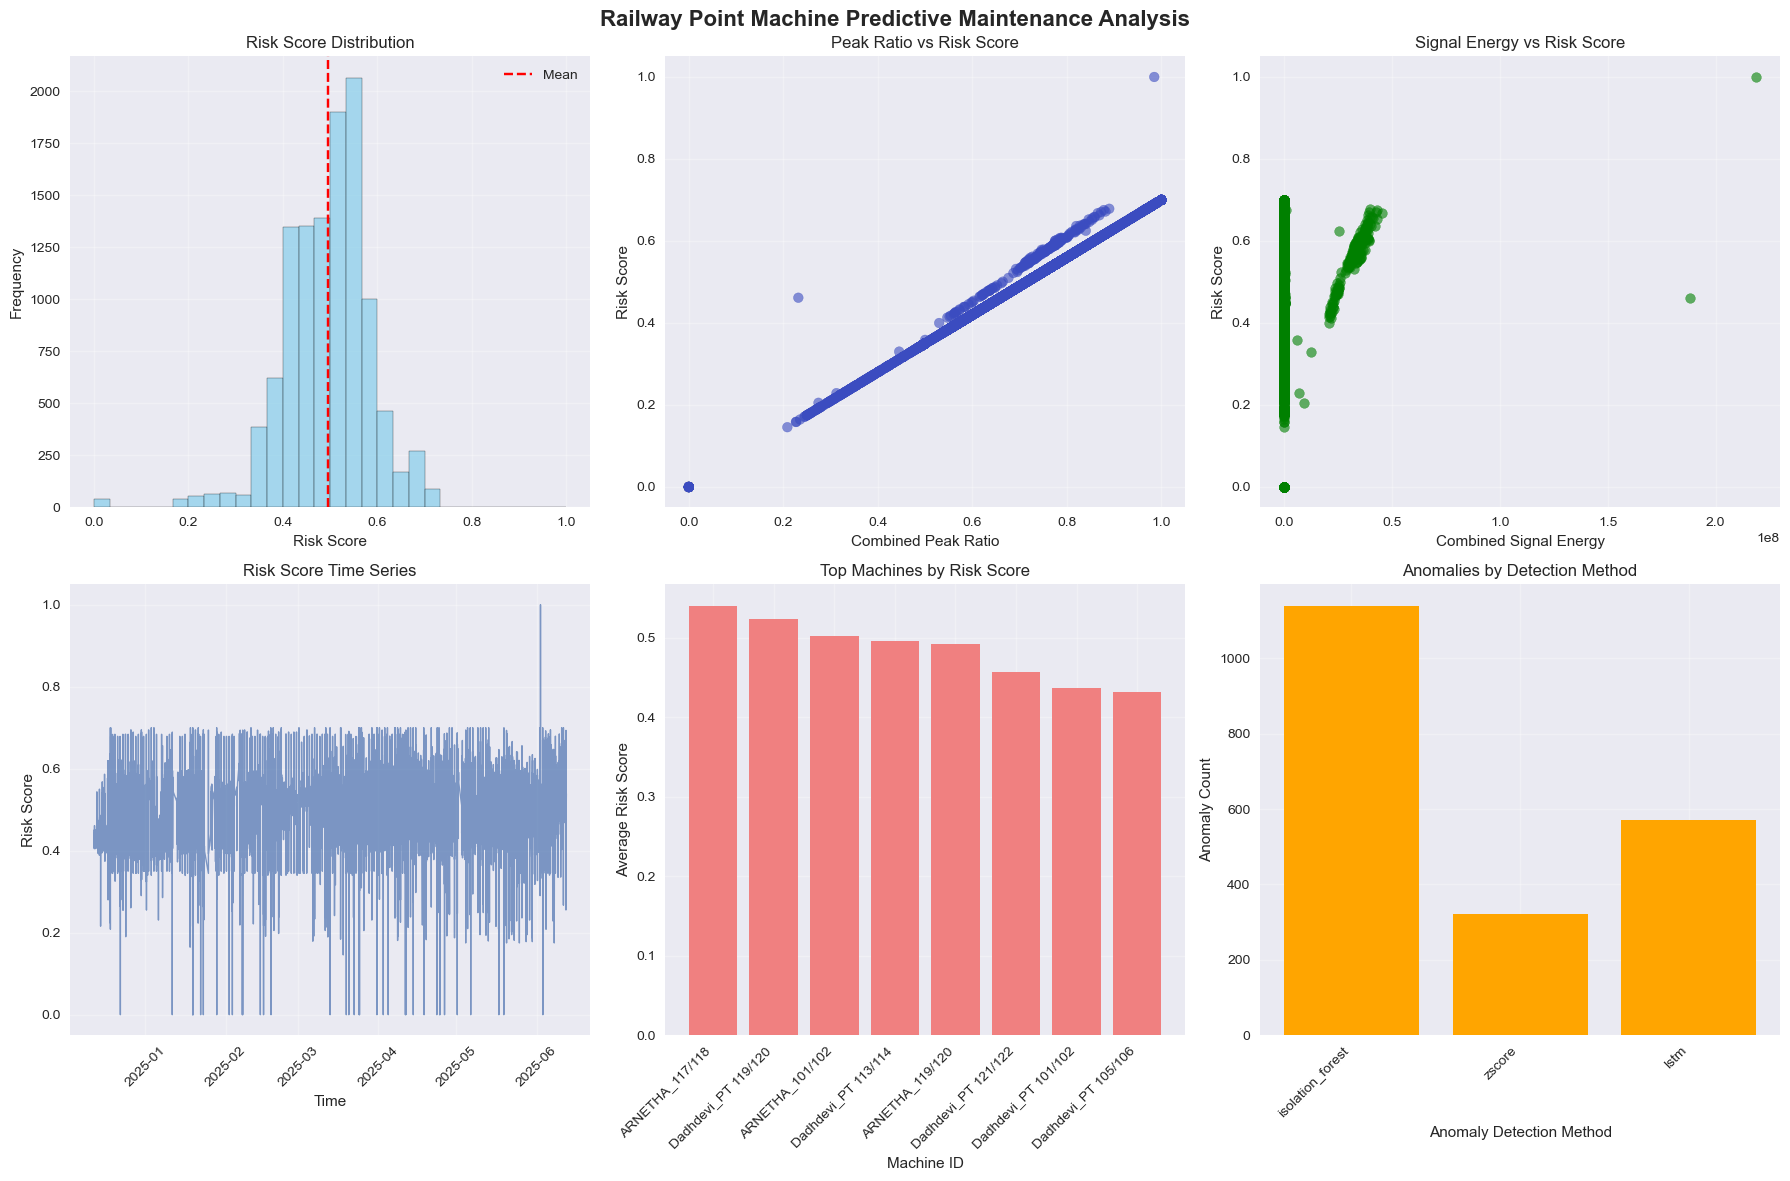

Visualization plots created and saved as 'railway_maintenance_analysis.png'

=== ADVANCED FEATURES DEMONSTRATION ===

1. Multi-scale Time Analysis:
STL decomposition data not available (requires more historical data)

2. Cross-sensor Correlation Analysis:
Current A vs Current B Energy Correlation: 0.6445

3. Failure Probability Estimation:
Machines with high risk (>0.7): 91/11397
Estimated failure probability for high-risk machines: 1.000

4. Maintenance Scheduling Recommendations:
Top 5 Machines for Immediate Maintenance:
  ARNETHA_117/118: Priority Score 0.424
  Dadhdevi_PT 119/120: Priority Score 0.411
  ARNETHA_101/102: Priority Score 0.395
  Dadhdevi_PT 113/114: Priority Score 0.389
  ARNETHA_119/120: Priority Score 0.386

5. Real-time Monitoring Simulation:
Simulating continuous monitoring...
  Time +0min: Monitoring 8 machines...
    ALERT: 129 machines exceed risk threshold!
  Time +5min: Monitoring 8 machines...
    ALERT: 109 machines exceed risk threshold!
  Time +10min: Mon

In [17]:
# Initialize and process pm_system if not already done
pm_system = RailwayPredictiveMaintenance()
pm_system.load_and_parse_data('/Users/anamikasaroha/Energy7_Week1/week_9/WCR_latest_TWS_cleaned_V2.csv')
pm_system.process_data_pipeline()
pm_system.train_anomaly_detection_models()

generate_machine_health_report(pm_system, output_file='machine_health_report.pdf')
create_visualization_plots(pm_system)
demo_advanced_features(pm_system)   

In [18]:
# Display rows where any anomaly has been detected
if 'combined_anomaly_flag' in pm_system.processed_data.columns:
    anomalies = pm_system.processed_data[pm_system.processed_data['combined_anomaly_flag'] == 1]
    print(anomalies)
else:
    print("No anomaly detection results available in processed data.")

                timestamp           machine_id site_name point_machine_name  \
169   2025-02-07 11:14:17      ARNETHA_101/102   ARNETHA            101/102   
189   2025-02-14 10:13:45      ARNETHA_101/102   ARNETHA            101/102   
201   2025-02-18 12:51:28      ARNETHA_101/102   ARNETHA            101/102   
209   2025-02-18 12:54:30      ARNETHA_101/102   ARNETHA            101/102   
218   2025-02-21 11:13:52      ARNETHA_101/102   ARNETHA            101/102   
...                   ...                  ...       ...                ...   
9082  2025-04-24 17:17:10  Dadhdevi_PT 121/122  Dadhdevi         PT 121/122   
9083  2025-04-24 17:17:09  Dadhdevi_PT 121/122  Dadhdevi         PT 121/122   
9321  2025-05-06 14:31:31  Dadhdevi_PT 121/122  Dadhdevi         PT 121/122   
10366 2025-01-19 10:17:25  Dadhdevi_PT 119/120  Dadhdevi         PT 119/120   
10469 2025-02-02 10:12:52  Dadhdevi_PT 119/120  Dadhdevi         PT 119/120   

      direction  hour  day_of_week  month  current_

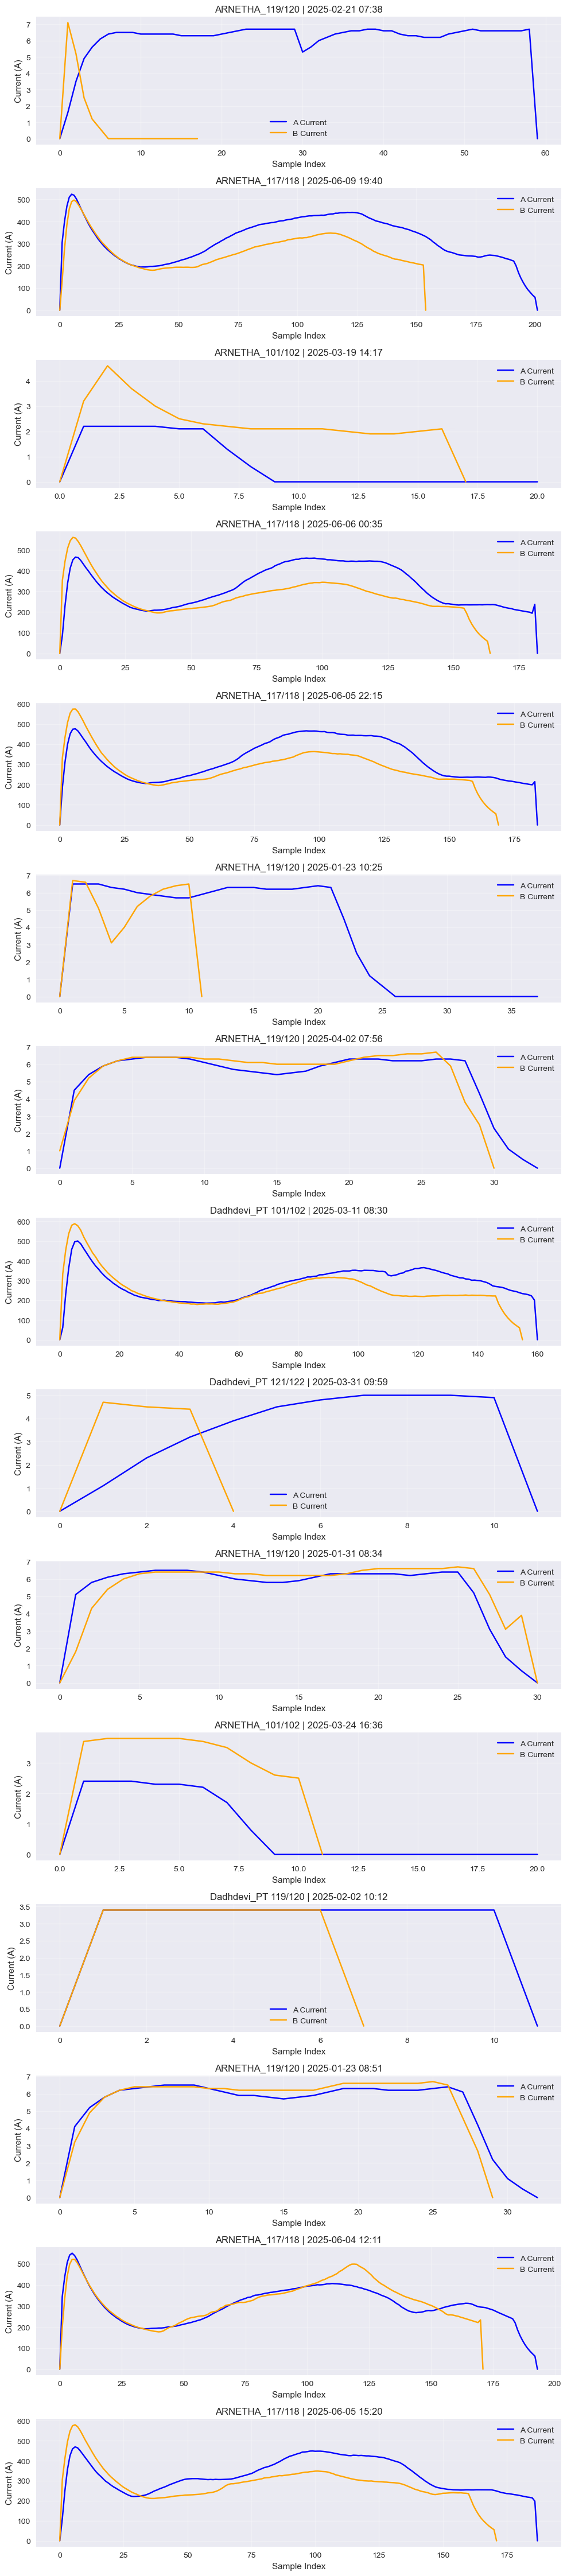

In [21]:
import ast

import matplotlib.pyplot as plt

# Ensure we have 15 axes for 15 samples
num_samples = len(sample_anomalies)
fig, axes = plt.subplots(num_samples, 1, figsize=(10, 3 * num_samples), sharex=False)
if num_samples == 1:
    axes = [axes]  # Ensure axes is always iterable

for idx, (i, row) in enumerate(sample_anomalies.iterrows()):
    # Find the original row in df by timestamp, machine_id, and point_machine_name
    match = df[
        (pd.to_datetime(df['Time']) == row['timestamp']) &
        (df['Site Name'] + '_' + df['Point Machine Name'] == row['machine_id'])
    ]
    ax = axes[idx]
    if not match.empty:
        # Parse current arrays if they are strings
        a_current = match.iloc[0]['A Current']
        b_current = match.iloc[0]['B Current']
        if isinstance(a_current, str):
            a_current = ast.literal_eval(a_current)
        if isinstance(b_current, str):
            b_current = ast.literal_eval(b_current)
        # Plot A Current
        ax.plot(a_current, label='A Current', color='blue')
        # Plot B Current
        ax.plot(b_current, label='B Current', color='orange')
        ax.set_title(f"{row['machine_id']} | {row['timestamp']:%Y-%m-%d %H:%M}")
        ax.legend()
        ax.set_xlabel('Sample Index')
        ax.set_ylabel('Current (A)')
        ax.grid(alpha=0.3)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

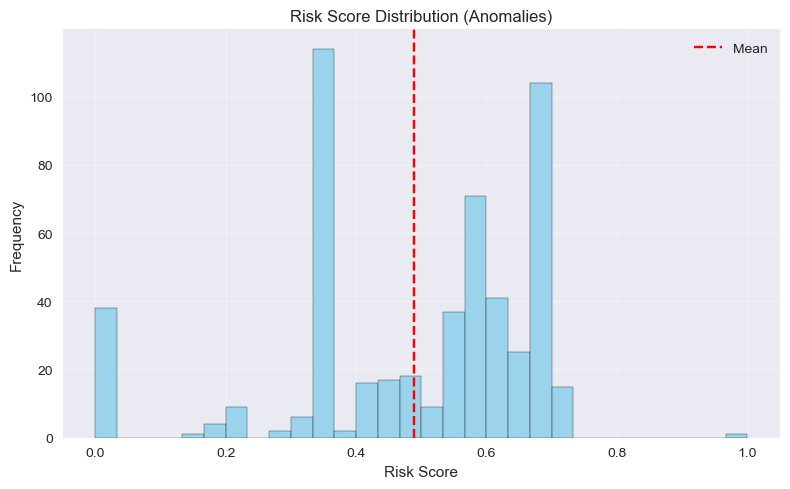

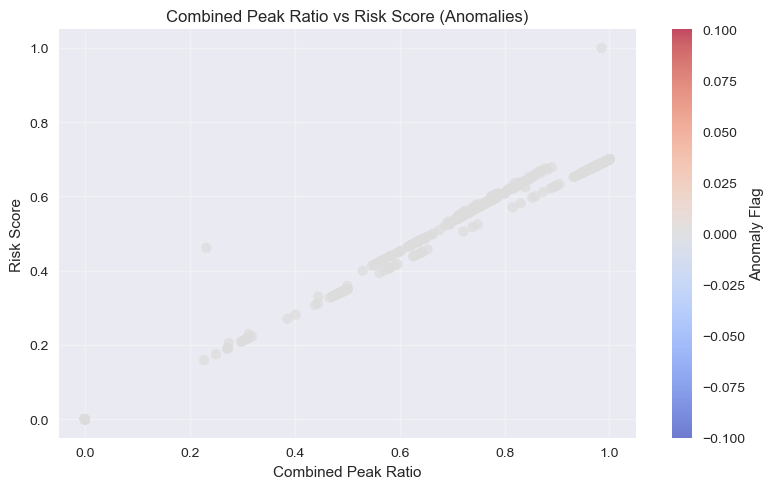

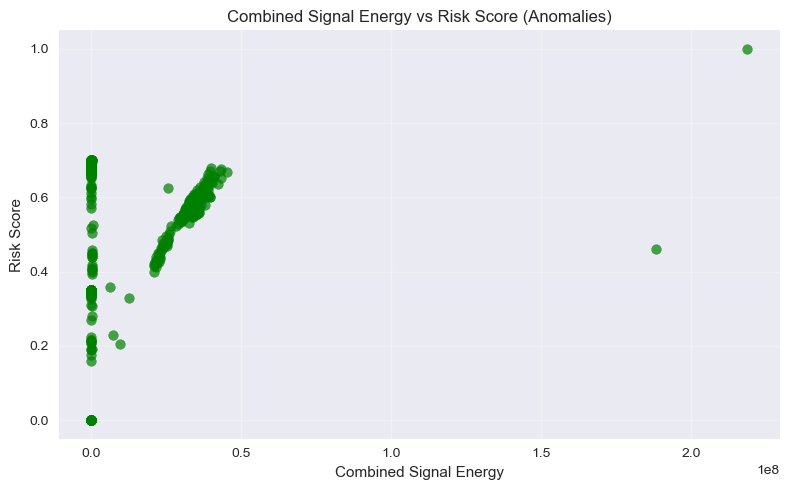

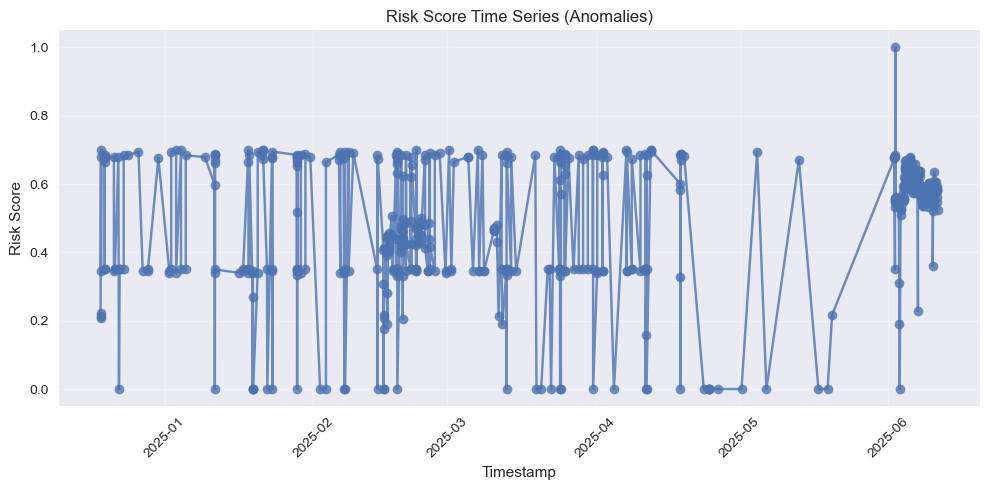

In [20]:
import matplotlib.pyplot as plt

# Plot 1: Risk Score Distribution
plt.figure(figsize=(8, 5))
plt.hist(anomalies['risk_score'], bins=30, color='skyblue', edgecolor='black', alpha=0.8)
plt.axvline(anomalies['risk_score'].mean(), color='red', linestyle='--', label='Mean')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.title('Risk Score Distribution (Anomalies)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Combined Peak Ratio vs Risk Score
plt.figure(figsize=(8, 5))
plt.scatter(anomalies['combined_peak_ratio'], anomalies['risk_score'], 
            c=anomalies['anomaly_flag'], cmap='coolwarm', alpha=0.7)
plt.xlabel('Combined Peak Ratio')
plt.ylabel('Risk Score')
plt.title('Combined Peak Ratio vs Risk Score (Anomalies)')
plt.colorbar(label='Anomaly Flag')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Combined Signal Energy vs Risk Score
plt.figure(figsize=(8, 5))
plt.scatter(anomalies['combined_signal_energy'], anomalies['risk_score'], 
            color='green', alpha=0.7)
plt.xlabel('Combined Signal Energy')
plt.ylabel('Risk Score')
plt.title('Combined Signal Energy vs Risk Score (Anomalies)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 4: Time Series of Risk Scores (Anomalies)
plt.figure(figsize=(10, 5))
sorted_anomalies = anomalies.sort_values('timestamp')
plt.plot(sorted_anomalies['timestamp'], sorted_anomalies['risk_score'], marker='o', linestyle='-', alpha=0.8)
plt.xlabel('Timestamp')
plt.ylabel('Risk Score')
plt.title('Risk Score Time Series (Anomalies)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()